# Eigenvalue problems

$x\neq 0$ is an eigenvector of $A$ with eigenvalue $\lambda$ if:

$$Ax = \lambda x$$

Fact 1: the eigenvalues of $A$ are the roots of the characteristic polynomial

$$p(\lambda) = \text{det}(\lambda I_n - A) = 0$$

Fact 2: A real matrix can have complex eigenvalues/eigenvectors

So, today we move from $\mathbb{R}$ to $\mathbb{C}$

The transpose $A^T$ becomes the complex conjugate transpose, $A^*$.

The notion of a symmetric matrix (with $A^T=A$) becomes a Hermitian matrix (with $A^*=A$)

Instead of orthogonal matrices (with $Q^TQ = I_n$), we have unitary matrices ($Q^*Q=I_n$)

Our two-norm, $\|x\|_2^2 = x^tx$, becomes $\|x\|_2^2 = x^*x$.

Fact 3: an $n\times n$ matrix has $n$ eigenvalues (may be repeated)

Fact 4: if $x$ is an eigenvector of $A$ with eigenvalue $\lambda$, then $cx$ is also an eigenvector of $A$ with eigenvalue $\lambda$

## The power method

Assume $A_{n\times n}$ has a set of $n$ linearly independent eigenvectors $x_1,x_2,\ldots, x_n$.

Pick a vector $q$. form the sequence $q,Aq,A^2q,A^3q,\ldots$

The eigenvector with the largest eigenvalue is given by:

$$\lim_{k\to \infty}A^kz$$

with $A^kq=q_k$, the largest eigenvalue is given by:

$$\lim_{k\to \infty}\frac{q_k^TAq_k}{q_k^Tq_k}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
S = np.random.randn(5,5)
D = np.diag([5,4,3,2,1])
A = np.linalg.inv(S).dot(D).dot(S)

In [3]:
A.shape

(5, 5)

In [4]:
# choose a vector

q = np.random.randn(5)
max_iter = 200
res = []
for i in range(max_iter):
    q = A.dot(q)
    q = q/np.linalg.norm(q)
    lam = q.T.dot(A).dot(q)
    res.append(np.linalg.norm(A.dot(q)-lam*q)/np.linalg.norm(A))

In [5]:
q

array([ 0.29931038, -0.11402496,  0.4235295 ,  0.74916902,  0.39595473])

In [6]:
lam

5.0

In [7]:
# residual
np.linalg.norm(A.dot(q)-lam*q)/np.linalg.norm(A) 

2.604285972316271e-17

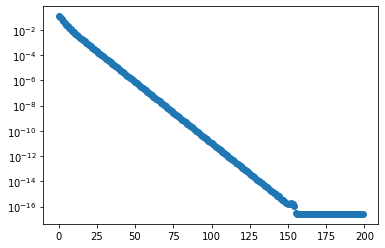

In [8]:
plt.semilogy(res,'o--')

In [9]:
## Rounding errors can be beneficial
A = np.array([[0.4,-0.6,0.2],[-0.3,0.7,-0.4],[-0.1,-0.4,0.5]])

q = np.array([1,1,1])

In [10]:
max_iter = 200
res = []
for i in range(max_iter):
    q = A.dot(q)
    q = q/np.linalg.norm(q)
    lam = q.T.dot(A).dot(q)
    res.append(np.linalg.norm(A.dot(q)-lam*q)/np.linalg.norm(A))

In [11]:
# residual
np.linalg.norm(A.dot(q)-lam*q)/np.linalg.norm(A) 

1.1971842761963994e-16

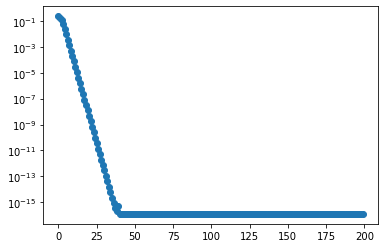

In [12]:
plt.semilogy(res,'o--')

## The inverse iteration

(The power method applied to $A^{-1}$

Theorem: $A$ is invertible if and only if all the eigenvalues are nonzero.

Upshot: if $x$ is an eigenvector of $A$ with eigenvalue $\lambda$, then $x$ is an eigenvector of $A^{-1}$ with eigenvalue $\frac{1}{\lambda}$ 

So, the the reciprocal of the smallest eigenvalue (in absolute value) of $A$ is the largest eigenvalue of $A^{-1}$.

To compute $q_{k+1} = A^-1q_k$, we solve $Aq_{k+1} = q_k$.

In [13]:
# random matrix with eigenvalues 1,2,3,4,5
S = np.random.randn(5,5)
D = np.diag([5,4,3,2,1])
A = np.linalg.inv(S).dot(D).dot(S)

We solve a Lot of linear systems in the following loop, so we import a scipy library that uses LU factors to do so efficiently.

In [14]:
from scipy.linalg import lu_factor
from scipy.linalg import lu_solve

In [15]:
q = np.random.randn(5)
max_iter = 100
res = []

lu,p = lu_factor(A)

for k in range(max_iter):
    q = lu_solve((lu,p),q)
    q =q/np.linalg.norm(q)
    lam = q.T.dot(A).dot(q) 
    res.append(np.linalg.norm(A.dot(q)-lam*q)/np.linalg.norm(A))
    

In [16]:
lam

1.000000000000006

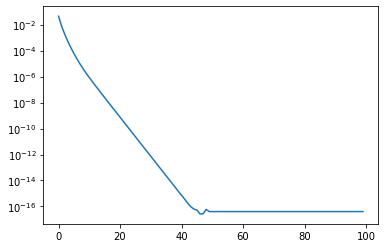

In [17]:
plt.semilogy(res)

## The shift - and - invert method

(The power method applied to $(A-\sigma I_n)^{-1}$)

$q_k = (A-\sigma I_n)^{-1})^kq$ approaches the eigenvector of $A$ with eigenvalue closest to the shift $\sigma$ 

In [18]:
shift = 2.1
max_iter = 100
res = []
lu,p = lu_factor(A-shift*np.eye(5))
q = np.random.randn(5)
for k in range(max_iter):
    q = lu_solve((lu,p),q)
    q = q/np.linalg.norm(q)
    lam = q.T.dot(A).dot(q)
    res.append(np.linalg.norm(A.dot(q)-lam*q)/np.linalg.norm(A))

In [19]:
lam

1.9999999999999971

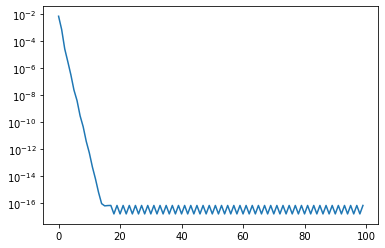

In [20]:
plt.semilogy(res)

# West0479 matrix

In [21]:
from scipy.io import mmread
A = mmread('west0479.mtx.gz')

In [22]:
A.shape

(479, 479)

In [23]:
A

<479x479 sparse matrix of type '<class 'numpy.float64'>'
	with 1910 stored elements in COOrdinate format>

In [24]:
# A as a dense amtrix
A = A.toarray()

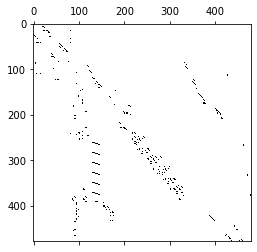

In [25]:
plt.spy(A)

In [26]:
# eigenvalues and eigenvector
evalues, evectors = np.linalg.eig(A)

In [27]:
evalues # in numpy j = sqrt(-1)

array([ 9.21360904e-03+1.70066232e+03j,  9.21360904e-03-1.70066232e+03j,
        1.08125256e+02+5.40659386e+01j,  1.08125256e+02-5.40659386e+01j,
       -7.24015165e+00+1.20672188e+02j, -7.24015165e+00-1.20672188e+02j,
       -1.00885104e+02+6.66062491e+01j, -1.00885104e+02-6.66062491e+01j,
       -7.46535209e+01+0.00000000e+00j, -2.33008454e+01+7.06894790e+01j,
       -2.33008454e+01-7.06894790e+01j,  5.97889701e+01+4.36888114e+01j,
        5.97889701e+01-4.36888114e+01j,  7.46354391e+01+0.00000000e+00j,
        4.30619433e+01+3.91642807e+01j,  4.30619433e+01-3.91642807e+01j,
       -3.51604828e+01+3.93977635e+01j, -3.51604828e+01-3.93977635e+01j,
        1.75485461e+01+3.42378225e+01j,  1.75485461e+01-3.42378225e+01j,
        3.37069530e+01+1.75567223e+01j,  3.37069530e+01-1.75567223e+01j,
        2.52160374e+01+2.52168500e+01j,  2.52160374e+01-2.52168500e+01j,
       -2.52159383e+01+2.52167700e+01j, -2.52159383e+01-2.52167700e+01j,
       -3.16797902e+01+1.71254837e+01j, -3.16797902

In [28]:
# the power method
n = A.shape[0]
q = np.random.randn(n)
max_iter = 50
res = []
for k in range(max_iter):
    q = A.dot(q)
    q = q/np.linalg.norm(q)
    lam = q.dot(A).dot(q)
    res.append(np.linalg.norm(A.dot(q)-lam*q)/np.linalg.norm(A))

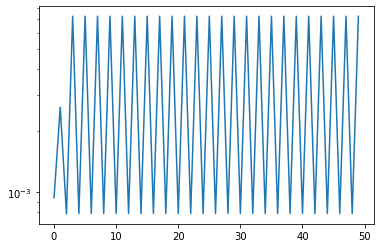

In [29]:
plt.semilogy(res)

In [30]:
# why doesn't this work? no gap between largest and second largest eigenvalues


np.sort(np.abs(evalues))[::-1]

array([1.70066232e+03, 1.70066232e+03, 1.20889192e+02, 1.20889192e+02,
       1.20889192e+02, 1.20889192e+02, 1.20889192e+02, 1.20889192e+02,
       7.46535209e+01, 7.46354391e+01, 7.44307183e+01, 7.44307183e+01,
       7.40502072e+01, 7.40502072e+01, 5.82080049e+01, 5.82080049e+01,
       5.28057130e+01, 5.28057130e+01, 3.84731070e+01, 3.84731070e+01,
       3.80052257e+01, 3.80052257e+01, 3.60123770e+01, 3.60123770e+01,
       3.56621044e+01, 3.56618691e+01, 3.56614367e+01, 3.56614367e+01,
       3.56613100e+01, 3.56613100e+01, 3.56608352e+01, 3.56608352e+01,
       3.49480351e+01, 3.49480351e+01, 3.48282376e+01, 3.48282376e+01,
       3.38714815e+01, 3.37389146e+01, 2.67568685e+01, 2.67568685e+01,
       1.93358785e+01, 1.93358785e+01, 1.88853827e+01, 1.88853827e+01,
       1.87003936e+01, 1.87003936e+01, 1.84185268e+01, 1.84185268e+01,
       1.83173600e+01, 1.83173600e+01, 1.81334485e+01, 1.81334485e+01,
       1.74207490e+01, 1.74207490e+01, 1.69324902e+01, 1.66634205e+01,
      

In [31]:
shift = 15+35j
max_iter = 100
res = []
lu,p = lu_factor(A-shift*np.eye(n))
q = np.random.randn(n)
for k in range(max_iter):
    q = lu_solve((lu,p),q)
    q = q/np.linalg.norm(q)
    lam = np.vdot(q,A.dot(q))
    res.append(np.linalg.norm(A.dot(q)-lam*q)/np.linalg.norm(A))

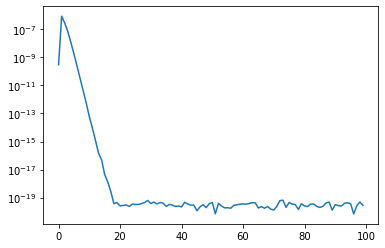

In [32]:
plt.semilogy(res)

In [33]:
# rayleigh iteration

shift = 15+35j
max_iter = 100
res = []
# lu,p = lu_factor(A-shift*np.eye(n))
q = np.random.randn(n)
for k in range(max_iter):
    q = np.linalg.solve(A-shift*np.eye(n),q) # O(n^3)
    # q = lu_solve((lu,p),q)
    q = q/np.linalg.norm(q)
    lam = np.vdot(q,A.dot(q))
    shift = lam
    res.append(np.linalg.norm(A.dot(q)-lam*q)/np.linalg.norm(A))

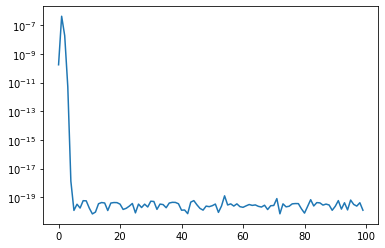

In [34]:
plt.semilogy(res)

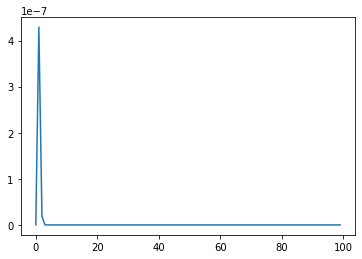

In [35]:
plt.plot(res)

## The QR method (np.linalg.eig)

We'll spend many class periods on this bad larry

Let $A$ ge a complex matrix.

for $k = 1,2,\ldots$:

1) Factor $A$ as $QR$ (ie, QR factorization)

2) A = RQ

As $k$ goes to infinity, $A$ goes to an upper triangular matrix with eigenvalues on the diagonal.

In [36]:
A = np.random.randn(5,5) +1j*np.random.randn(5,5)
evals,evecs = np.linalg.eig(A)

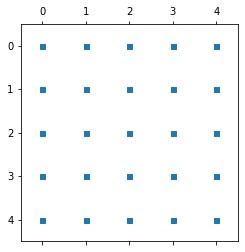

In [37]:
plt.spy(A,markersize=5,precision = 1e-4)

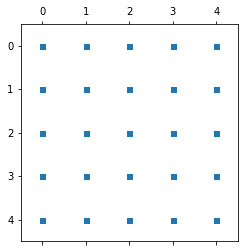

In [38]:
for k in range(1000):
    Q,R = np.linalg.qr(A)
    A = R.dot(Q)
    plt.spy(A,markersize=5,precision = 1e-4)

In [39]:
np.sort(np.diag(A))

array([-1.63305141+0.18714229j, -1.11082754-2.00235936j,
       -0.30772548-1.92991495j,  1.85404533+0.75963878j,
        1.86750688-1.0791227j ])

In [40]:
np.sort(evals)

array([-1.63305141+0.18714229j, -1.11082754-2.00235936j,
       -0.30772548-1.92991495j,  1.85404533+0.75963878j,
        1.86750688-1.0791227j ])